# Factorization Machines — Context-Aware Personalized Recommendations

**Part 2c of the Recommendation System Module**

| Aspect | Detail |
|--------|--------|
| **PRD Requirement** | Adaptation des recommandations au contexte (Time/Context Filtering) |
| **Model** | Factorization Machines (FM) |
| **Category** | Context-Aware Collaborative Filtering |
| **Training** | Stochastic Gradient Descent (SGD) with epochs |
| **Comparison** | FM feature configs vs SVD (from notebook 02a) vs Popularity Baseline |

---

### Why Factorization Machines?

SVD only sees two dimensions: **User** and **Item**. It can't answer "what should this user buy *right now*?"

FM adds context: time of day, day of week, meal period, restaurant type, item category. It learns that User 42 orders Espresso at Cafés on weekday mornings but Steak Fajitas at Restaurants on Friday evenings.

### FM Prediction Formula

$$\hat{y}(x) = w_0 + \sum_{i=1}^{n} w_i x_i + \sum_{i=1}^{n} \sum_{j=i+1}^{n} \langle v_i, v_j \rangle x_i x_j$$

Where:
- $w_0$ = global bias
- $w_i$ = weight for feature i
- $\langle v_i, v_j \rangle$ = dot product of latent vectors — captures pairwise feature interactions
- The feature vector $x$ includes: user_id, item_id, hour, day_of_week, meal_period, is_weekend, restaurant_type, category

### Training

FM is trained with **SGD (Stochastic Gradient Descent)** over multiple **epochs** — same training paradigm as neural networks, but with a simpler architecture.

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import os
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATASETS_DIR = os.path.join('..', 'datasets')
ALS_DIR = os.path.join('..', 'ALS')
SVD_DIR = os.path.join('..', 'SVD')
FM_DIR = os.path.join('..', 'FM')

print('Setup complete.')

Setup complete.


---
## 2. Load Data & Feature Engineering

In [2]:
df = pd.read_csv(os.path.join(DATASETS_DIR, 'enterprise_pos_dataset.csv'), sep='|')
customers_df = pd.read_csv(os.path.join(DATASETS_DIR, 'customers.csv'))

print(f'Transactions:     {len(df):,} rows')
print(f'Unique customers: {df["customer_id"].nunique()}')
print(f'Unique items:     {df["item_name"].nunique()}')
print(f'Categories:       {df["category"].nunique()} — {list(df["category"].unique())}')
print(f'Restaurant types: {df["restaurant_type"].nunique()} — {list(df["restaurant_type"].unique())}')
print(f'Columns:          {list(df.columns)}')
df.head()

Transactions:     178,839 rows
Unique customers: 9991
Unique items:     122
Categories:       8 — ['Food', 'Beverage', 'Bakery', 'Main', 'Appetizer', 'Side', 'Alcohol', 'Dessert']
Restaurant types: 7 — ['Cafe', 'American', 'Italian', 'Mexican', 'Japanese', 'Healthy_Vegan', 'Steakhouse']
Columns:          ['order_details_id', 'order_id', 'order_date', 'order_time', 'item_name', 'category', 'price', 'restaurant_type', 'item_id', 'customer_id', 'cashier_id', 'payment_method', 'table_number', 'is_voided', 'void_reason', 'discount_pct', 'line_total']


,order_details_id,order_id,order_date,order_time,item_name,category,price,restaurant_type,item_id,customer_id,cashier_id,payment_method,table_number,is_voided,void_reason,discount_pct,line_total
0,500000,100000,2023-01-01,07:30 AM,Oatmeal with Berries,Food,5.50,Cafe,80,520,C02,card,12.0,False,NaN,0.0,5.50
1,500001,100000,2023-01-01,07:30 AM,Cold Brew Coffee,Beverage,4.50,Cafe,35,520,C02,card,12.0,False,NaN,0.0,4.50
2,500002,100000,2023-01-01,07:30 AM,Fruit Smoothie,Beverage,6.50,Cafe,50,520,C02,card,12.0,False,NaN,0.0,6.50
3,500003,100001,2023-01-01,08:00 AM,Almond Croissant,Bakery,4.25,Cafe,4,6381,C03,cash,21.0,False,NaN,0.0,4.25
4,500004,100001,2023-01-01,08:00 AM,Everything Bagel with Cream Cheese,Bakery,4.50,Cafe,46,6381,C03,cash,21.0,False,NaN,0.0,4.50


In [3]:
# Parse date and time columns
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_time'] = pd.to_datetime(df['order_time'], format='%I:%M %p', errors='coerce')

# Fallback if parsing failed
if df['order_time'].isna().sum() > len(df) * 0.5:
    print('WARNING: Time parsing with %I:%M %p failed. Trying alternative formats...')
    df['order_time'] = pd.to_datetime(df['order_time'], errors='coerce')

# Extract contextual features
df['hour'] = df['order_time'].dt.hour
df['day_of_week'] = df['order_date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

def get_meal_period(hour):
    if pd.isna(hour):
        return 'unknown'
    hour = int(hour)
    if 6 <= hour < 11:
        return 'breakfast'
    elif 11 <= hour < 15:
        return 'lunch'
    elif 15 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 23:
        return 'dinner'
    else:
        return 'late_night'

df['meal_period'] = df['hour'].apply(get_meal_period)

print(f'\nFeatures extracted:')
print(f'  Hour range:     {df["hour"].min():.0f} - {df["hour"].max():.0f}')
print(f'  Day of week:    {df["day_of_week"].min()} - {df["day_of_week"].max()}')
print(f'  Weekend ratio:  {df["is_weekend"].mean():.1%}')
print(f'  Meal periods:   {df["meal_period"].value_counts().to_dict()}')
print(f'  NaN hours:      {df["hour"].isna().sum()}')


Features extracted:
  Hour range:     0 - 23
  Day of week:    0 - 6
  Weekend ratio:  33.0%
  Meal periods:   {'dinner': 111428, 'lunch': 37792, 'breakfast': 29443, 'late_night': 176}
  NaN hours:      0


---
## 3. Contextual EDA

Before building FM, we verify that context matters — do people buy different things at different times and restaurant types?

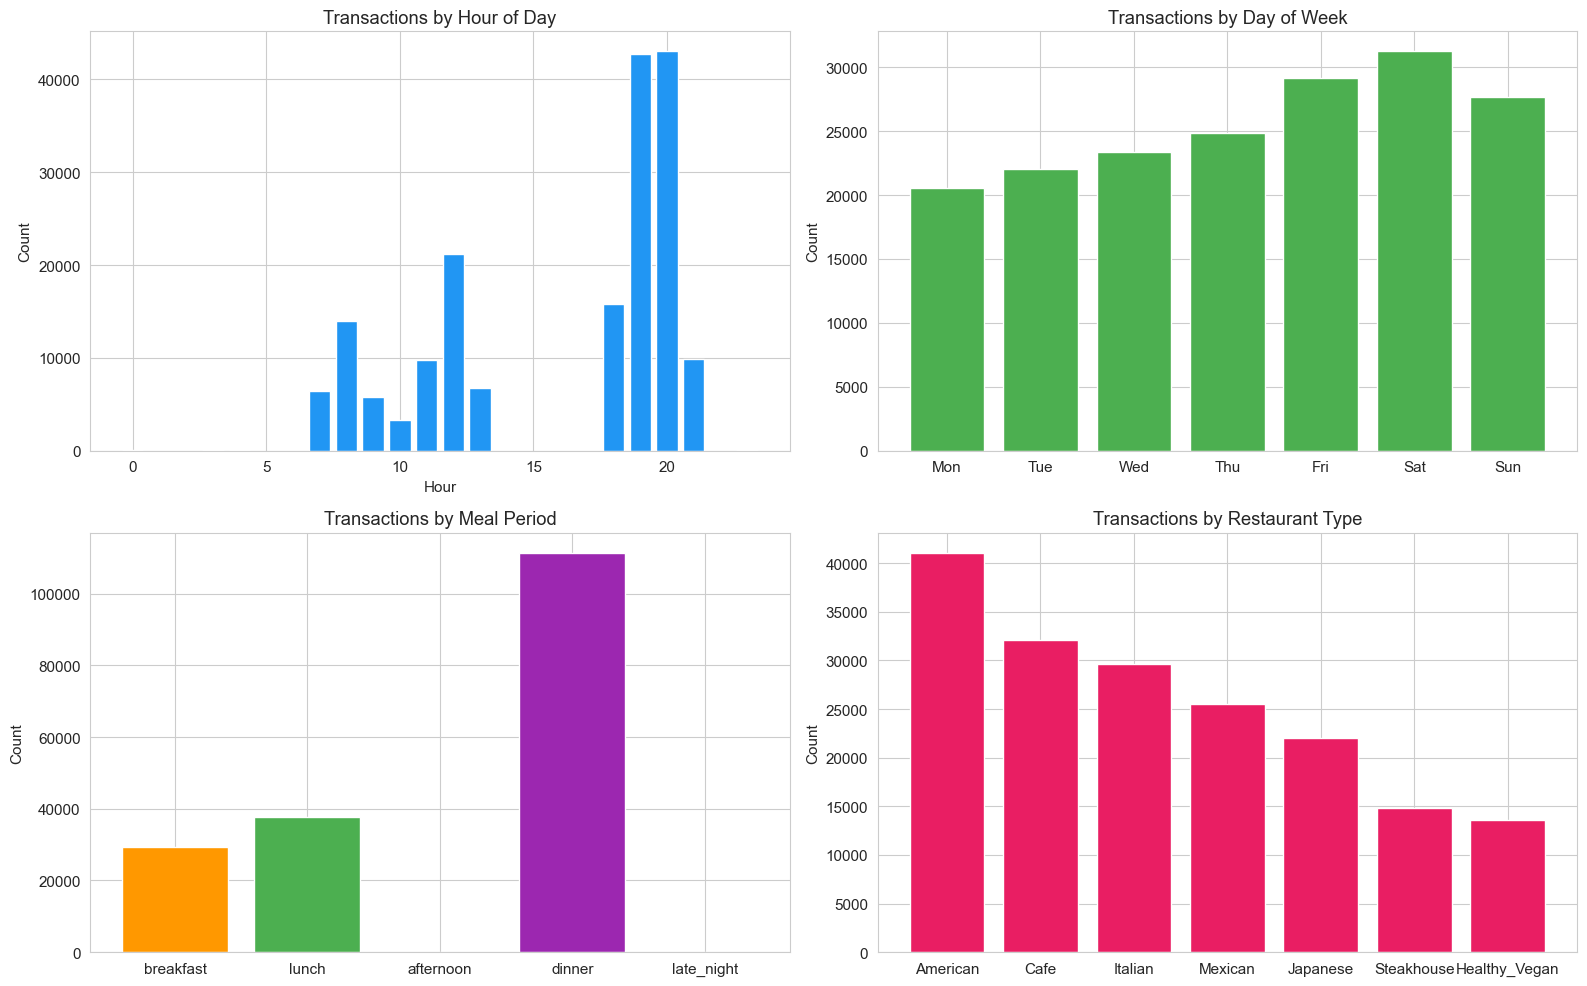

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

hourly = df.groupby('hour').size()
axes[0, 0].bar(hourly.index, hourly.values, color='#2196F3', edgecolor='white')
axes[0, 0].set_title('Transactions by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Count')

daily = df.groupby('day_of_week').size()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(daily.index, daily.values, color='#4CAF50', edgecolor='white')
axes[0, 1].set_title('Transactions by Day of Week')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_labels)
axes[0, 1].set_ylabel('Count')

meal_order = ['breakfast', 'lunch', 'afternoon', 'dinner', 'late_night']
meal_counts = df['meal_period'].value_counts().reindex(meal_order, fill_value=0)
colors_meal = ['#FF9800', '#4CAF50', '#03A9F4', '#9C27B0', '#607D8B']
axes[1, 0].bar(meal_counts.index, meal_counts.values, color=colors_meal, edgecolor='white')
axes[1, 0].set_title('Transactions by Meal Period')
axes[1, 0].set_ylabel('Count')

rest_counts = df['restaurant_type'].value_counts()
axes[1, 1].bar(rest_counts.index, rest_counts.values, color='#E91E63', edgecolor='white')
axes[1, 1].set_title('Transactions by Restaurant Type')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [5]:
print('Top 5 items per meal period:')
print('=' * 60)

for period in ['breakfast', 'lunch', 'dinner']:
    period_df = df[df['meal_period'] == period]
    if len(period_df) == 0:
        print(f'\n  {period.upper()}: No transactions')
        continue
    top_items = period_df['item_name'].value_counts().head(5)
    print(f'\n  {period.upper()} ({len(period_df):,} transactions):')
    for item, count in top_items.items():
        print(f'    {item}: {count}')

print('\n' + '=' * 60)
print('If the top items differ across meal periods → context matters → FM adds value.')

Top 5 items per meal period:

  BREAKFAST (29,443 transactions):
    Avocado Toast: 2619
    Oatmeal with Berries: 2605
    Breakfast Sandwich (Egg & Cheese): 2376
    Cold Brew Coffee: 1952
    Blueberry Muffin: 1930

  LUNCH (37,792 transactions):
    Hot Dog with Mustard: 2196
    Chicken Tenders (4pc): 1821
    Bacon Double Burger: 1793
    Spicy BBQ Bacon Burger: 1762
    Acai Berry Bowl: 1718

  DINNER (111,428 transactions):
    Salmon Nigiri (2pc): 2453
    California Roll: 2377
    Spicy Tuna Roll: 2270
    Pork Carnitas Bowl: 2217
    Beef Tacos (3pc): 2184

If the top items differ across meal periods → context matters → FM adds value.


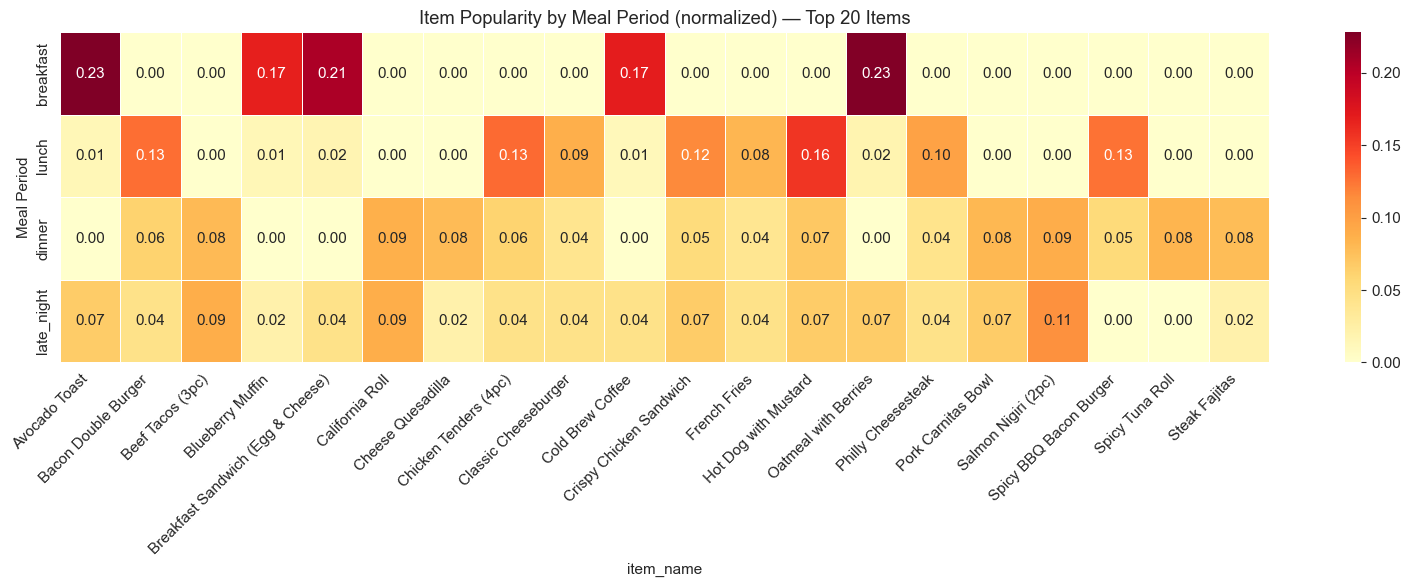

In [6]:
# Heatmap: item popularity by meal period
top_20 = df['item_name'].value_counts().head(20).index.tolist()
subset = df[df['item_name'].isin(top_20)]

heatmap_data = subset.groupby(['meal_period', 'item_name']).size().unstack(fill_value=0)
meal_order_available = [m for m in meal_order if m in heatmap_data.index]
heatmap_data = heatmap_data.reindex(meal_order_available)
heatmap_normalized = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_normalized, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Item Popularity by Meal Period (normalized) — Top 20 Items')
ax.set_ylabel('Meal Period')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

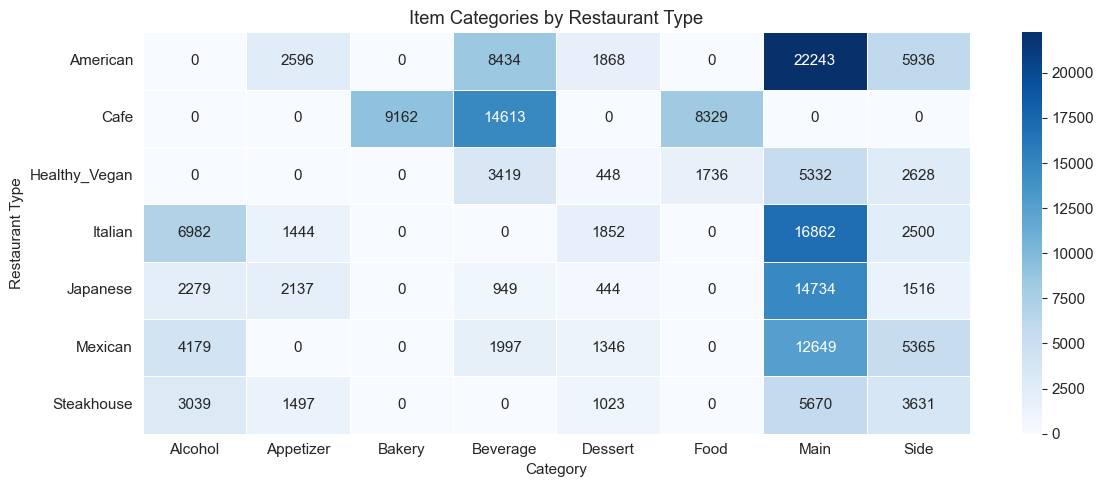

In [7]:
# Category by restaurant type
cat_rest = df.groupby(['restaurant_type', 'category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cat_rest, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Item Categories by Restaurant Type')
ax.set_ylabel('Restaurant Type')
ax.set_xlabel('Category')
plt.tight_layout()
plt.show()

---
## 4. Encode Features & Prepare FM Training Data

In [8]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
meal_encoder = LabelEncoder()
restaurant_encoder = LabelEncoder()
category_encoder = LabelEncoder()

df['user_idx'] = user_encoder.fit_transform(df['customer_id'])
df['item_idx'] = item_encoder.fit_transform(df['item_name'])
df['meal_idx'] = meal_encoder.fit_transform(df['meal_period'])
df['restaurant_idx'] = restaurant_encoder.fit_transform(df['restaurant_type'])
df['category_idx'] = category_encoder.fit_transform(df['category'])

n_users = df['user_idx'].nunique()
n_items = df['item_idx'].nunique()
n_meals = df['meal_idx'].nunique()
n_days = 7
n_restaurants = df['restaurant_idx'].nunique()
n_categories = df['category_idx'].nunique()

print(f'Encoded dimensions:')
print(f'  Users:            {n_users}')
print(f'  Items:            {n_items}')
print(f'  Meal periods:     {n_meals} ({list(meal_encoder.classes_)})')
print(f'  Restaurant types: {n_restaurants} ({list(restaurant_encoder.classes_)})')
print(f'  Categories:       {n_categories} ({list(category_encoder.classes_)})')

Encoded dimensions:
  Users:            9991
  Items:            122
  Meal periods:     4 (['breakfast', 'dinner', 'late_night', 'lunch'])
  Restaurant types: 7 (['American', 'Cafe', 'Healthy_Vegan', 'Italian', 'Japanese', 'Mexican', 'Steakhouse'])
  Categories:       8 (['Alcohol', 'Appetizer', 'Bakery', 'Beverage', 'Dessert', 'Food', 'Main', 'Side'])


In [9]:
# Build positive samples
positive_samples = df.groupby(
    ['user_idx', 'item_idx', 'hour', 'day_of_week', 'is_weekend', 'meal_idx', 'restaurant_idx', 'category_idx']
).size().reset_index(name='count')
positive_samples['label'] = 1
print(f'Positive samples: {len(positive_samples):,}')

# Negative sampling
NEG_RATIO = 2
all_items = set(range(n_items))
item_category_map = df.groupby('item_idx')['category_idx'].first().to_dict()

neg_samples_list = []
for _, row in positive_samples.iterrows():
    user = row['user_idx']
    context_items = set(positive_samples[
        (positive_samples['user_idx'] == user) & (positive_samples['meal_idx'] == row['meal_idx'])
    ]['item_idx'])
    negative_items = list(all_items - context_items)
    neg_chosen = np.random.choice(negative_items, size=min(NEG_RATIO, len(negative_items)), replace=False)
    for neg_item in neg_chosen:
        neg_samples_list.append({
            'user_idx': user, 'item_idx': neg_item, 'hour': row['hour'],
            'day_of_week': row['day_of_week'], 'is_weekend': row['is_weekend'],
            'meal_idx': row['meal_idx'], 'restaurant_idx': row['restaurant_idx'],
            'category_idx': item_category_map.get(neg_item, 0), 'count': 0, 'label': 0
        })

negative_samples = pd.DataFrame(neg_samples_list)
print(f'Negative samples: {len(negative_samples):,}')

fm_data = pd.concat([positive_samples, negative_samples], ignore_index=True)
fm_data = fm_data.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Total FM samples: {len(fm_data):,} ({len(negative_samples)/len(positive_samples):.1f}:1 neg:pos)')

Positive samples: 174,041
Negative samples: 347,516
Total FM samples: 521,557 (2.0:1 neg:pos)


In [10]:
train_data, test_data = train_test_split(fm_data, test_size=0.2, random_state=42, stratify=fm_data['label'])

print(f'Train: {len(train_data):,} (pos: {train_data["label"].sum():,}, neg: {(train_data["label"]==0).sum():,})')
print(f'Test:  {len(test_data):,} (pos: {test_data["label"].sum():,}, neg: {(test_data["label"]==0).sum():,})')

Train: 417,245 (pos: 139,233, neg: 278,012)
Test:  104,312 (pos: 34,808, neg: 69,504)


---
## 5. Build Feature Matrices — Progressive Configurations

| Config | Features | Purpose |
|--------|----------|---------|
| 1 | User + Item | Baseline (comparable to SVD) |
| 2 | + Meal Period | Time-of-day awareness |
| 3 | + Day of Week + Weekend | Weekly patterns |
| 4 | + Hour + Restaurant Type + Category | Full context |

In [11]:
def build_feature_matrix(data, config='full'):
    n = len(data)
    user_oh = csr_matrix((np.ones(n), (np.arange(n), data['user_idx'].values)), shape=(n, n_users))
    item_oh = csr_matrix((np.ones(n), (np.arange(n), data['item_idx'].values)), shape=(n, n_items))
    parts = [user_oh, item_oh]

    if config in ['meal', 'day', 'full']:
        meal_oh = csr_matrix((np.ones(n), (np.arange(n), data['meal_idx'].values)), shape=(n, n_meals))
        parts.append(meal_oh)

    if config in ['day', 'full']:
        day_oh = csr_matrix((np.ones(n), (np.arange(n), data['day_of_week'].values)), shape=(n, n_days))
        parts.append(day_oh)
        parts.append(csr_matrix(data['is_weekend'].values.reshape(-1, 1).astype(float)))

    if config == 'full':
        parts.append(csr_matrix((data['hour'].values / 23.0).reshape(-1, 1)))
        rest_oh = csr_matrix((np.ones(n), (np.arange(n), data['restaurant_idx'].values)), shape=(n, n_restaurants))
        parts.append(rest_oh)
        cat_oh = csr_matrix((np.ones(n), (np.arange(n), data['category_idx'].values)), shape=(n, n_categories))
        parts.append(cat_oh)

    return hstack(parts, format='csr')


configs = {
    'user_item': 'User + Item',
    'meal':      'User + Item + Meal Period',
    'day':       'User + Item + Meal + Day + Weekend',
    'full':      'User + Item + Meal + Day + Weekend + Hour + Restaurant + Category'
}

X_train, X_test = {}, {}
for ck, cn in configs.items():
    X_train[ck] = build_feature_matrix(train_data, config=ck)
    X_test[ck] = build_feature_matrix(test_data, config=ck)
    print(f'{cn:<55} | Features: {X_train[ck].shape[1]}')

y_train = train_data['label'].values.astype(float)
y_test = test_data['label'].values.astype(float)
print(f'\nTrain: {len(y_train):,} | Test: {len(y_test):,}')

User + Item                                             | Features: 10113
User + Item + Meal Period                               | Features: 10117
User + Item + Meal + Day + Weekend                      | Features: 10125
User + Item + Meal + Day + Weekend + Hour + Restaurant + Category | Features: 10141

Train: 417,245 | Test: 104,312


---
## 6. FM Implementation — SGD Training from Scratch

In [12]:
class FactorizationMachine:
    """
    Factorization Machine for binary classification.
    Trained with mini-batch SGD.
    Based on: "Factorization Machines" (Steffen Rendle, 2010)
    """
    def __init__(self, n_factors=10, lr=0.01, reg=0.01, n_epochs=20, batch_size=256):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.w0 = 0.0
        self.w = None
        self.V = None
        self.train_losses = []
        self.val_losses = []

    def _sigmoid(self, x):
        return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))

    def _predict_raw(self, X):
        linear = X.dot(self.w) + self.w0
        XV = X.dot(self.V)
        XV_sq = np.array(XV ** 2)
        X_sq_V_sq = np.array(X.power(2).dot(self.V ** 2))
        interaction = 0.5 * np.sum(XV_sq - X_sq_V_sq, axis=1)
        return linear + interaction

    def predict_proba(self, X):
        return self._sigmoid(self._predict_raw(X))

    def _log_loss(self, y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n_samples, n_features = X_train.shape
        self.w = np.zeros(n_features)
        self.V = np.random.normal(0, 0.1, (n_features, self.n_factors))
        self.w0 = 0.0
        self.train_losses = []
        self.val_losses = []
        n_batches = int(np.ceil(n_samples / self.batch_size))

        print(f'  Training FM: {n_samples:,} samples, {n_features} features, k={self.n_factors}')
        print(f'  Hyperparams: lr={self.lr}, reg={self.reg}, epochs={self.n_epochs}, batch={self.batch_size}')
        print(f'  {"Epoch":>7} | {"Train Loss":>11} | {"Val Loss":>11} | {"Time":>8}')
        print(f'  {"-"*7}-+-{"-"*11}-+-{"-"*11}-+-{"-"*8}')

        indices = np.arange(n_samples)
        for epoch in range(self.n_epochs):
            start_time = time.time()
            np.random.shuffle(indices)
            epoch_loss = 0.0

            for batch_idx in range(n_batches):
                bs = batch_idx * self.batch_size
                be = min(bs + self.batch_size, n_samples)
                bi = indices[bs:be]
                X_b, y_b = X_train[bi], y_train[bi]
                bsz = len(y_b)

                y_pred = self._sigmoid(self._predict_raw(X_b))
                error = y_pred - y_b

                self.w0 -= self.lr * np.mean(error)
                grad_w = X_b.T.dot(error) / bsz + self.reg * self.w
                self.w -= self.lr * np.array(grad_w).flatten()

                XV = X_b.dot(self.V)
                for f in range(self.n_factors):
                    xv_f = np.array(XV[:, f]).flatten()
                    t1 = X_b.T.dot(error * xv_f) / bsz
                    t2 = X_b.power(2).T.dot(error) / bsz * self.V[:, f]
                    grad_vf = np.array(t1).flatten() - np.array(t2).flatten() + self.reg * self.V[:, f]
                    self.V[:, f] -= self.lr * grad_vf

                epoch_loss += self._log_loss(y_b, y_pred) * bsz

            avg_loss = epoch_loss / n_samples
            self.train_losses.append(avg_loss)
            val_str = '    N/A    '
            if X_val is not None and y_val is not None:
                vl = self._log_loss(y_val, self.predict_proba(X_val))
                self.val_losses.append(vl)
                val_str = f'{vl:>11.6f}'

            print(f'  {epoch+1:>7} | {avg_loss:>11.6f} | {val_str} | {time.time()-start_time:>7.2f}s')

        print(f'\n  Training complete. Final loss: {self.train_losses[-1]:.6f}')
        return self

print('FactorizationMachine class defined.')

FactorizationMachine class defined.


---
## 7. Train FM — All Feature Configurations

In [13]:
fm_results = {}

for config_key, config_name in configs.items():
    print(f'\n{"=" * 70}')
    print(f'CONFIG: {config_name}')
    print(f'{"=" * 70}')

    fm = FactorizationMachine(
    n_factors=20,       # was 10 — more capacity for context interactions
    lr=0.05,            # was 0.01 — faster learning for interaction terms
    reg=0.001,          # was 0.01 — stop suppressing V growth
    n_epochs=50,        # was 25 — give interactions time to develop
    batch_size=64       # was 256 — smaller batches = noisier gradients = escapes local minima
)
    fm.fit(X_train[config_key], y_train, X_test[config_key], y_test)

    test_pred = fm.predict_proba(X_test[config_key])
    threshold = np.percentile(test_pred, 100 * (1 - y_test.mean()))
    test_binary = (test_pred >= threshold).astype(int)

    fm_results[config_key] = {
        'name': config_name, 'model': fm,
        'test_loss': fm._log_loss(y_test, test_pred),
        'accuracy': accuracy_score(y_test, test_binary),
        'precision': precision_score(y_test, test_binary, zero_division=0),
        'recall': recall_score(y_test, test_binary, zero_division=0),
        'f1': f1_score(y_test, test_binary, zero_division=0),
        'auc': roc_auc_score(y_test, test_pred)
    }
    r = fm_results[config_key]
    print(f'\n  Test: Loss={r["test_loss"]:.4f} | Acc={r["accuracy"]:.4f} | Prec={r["precision"]:.4f} | Rec={r["recall"]:.4f} | F1={r["f1"]:.4f} | AUC={r["auc"]:.4f}')


CONFIG: User + Item
  Training FM: 417,245 samples, 10113 features, k=20
  Hyperparams: lr=0.05, reg=0.001, epochs=50, batch=64
    Epoch |  Train Loss |    Val Loss |     Time
  --------+-------------+-------------+---------
        1 |    0.625969 |    0.619014 |   24.25s
        2 |    0.615887 |    0.614660 |   24.09s
        3 |    0.613239 |    0.613323 |   24.44s
        4 |    0.612345 |    0.612841 |   25.29s
        5 |    0.611998 |    0.612717 |   24.94s
        6 |    0.611847 |    0.612869 |   24.75s
        7 |    0.611780 |    0.612615 |   24.69s
        8 |    0.611769 |    0.612609 |   24.80s
        9 |    0.611775 |    0.612608 |   25.27s
       10 |    0.611763 |    0.612602 |   25.04s
       11 |    0.611740 |    0.612610 |   24.89s
       12 |    0.611783 |    0.612595 |   24.86s
       13 |    0.611759 |    0.612740 |   25.63s
       14 |    0.611777 |    0.612610 |   25.84s
       15 |    0.611726 |    0.612647 |   25.56s
       16 |    0.611763 |    0.612614 

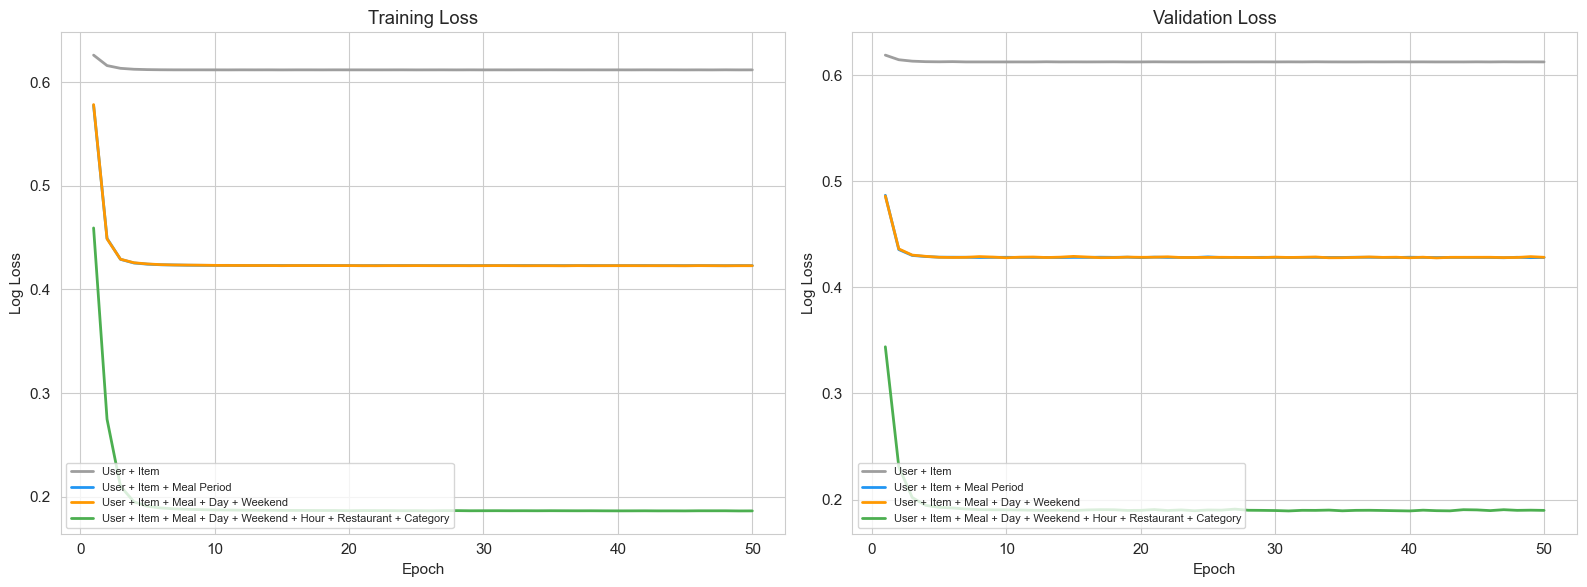

In [14]:
# Training convergence
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_config = ['#9E9E9E', '#2196F3', '#FF9800', '#4CAF50']

for (ck, res), color in zip(fm_results.items(), colors_config):
    m = res['model']
    ep = range(1, len(m.train_losses) + 1)
    axes[0].plot(ep, m.train_losses, linewidth=2, color=color, label=res['name'])
    if m.val_losses:
        axes[1].plot(ep, m.val_losses, linewidth=2, color=color, label=res['name'])

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Log Loss'); axes[0].set_title('Training Loss'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Log Loss'); axes[1].set_title('Validation Loss'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. Feature Configuration Comparison

In [15]:
print('=' * 95)
print('FM FEATURE CONFIGURATION COMPARISON')
print('=' * 95)
print(f'{"Config":<55} | {"Loss":>7} | {"Acc":>6} | {"Prec":>6} | {"Rec":>6} | {"F1":>6} | {"AUC":>6}')
print(f'{"-"*55}-+-{"-"*7}-+-{"-"*6}-+-{"-"*6}-+-{"-"*6}-+-{"-"*6}-+-{"-"*6}')
for ck, r in fm_results.items():
    print(f'{r["name"]:<55} | {r["test_loss"]:>7.4f} | {r["accuracy"]:>6.4f} | {r["precision"]:>6.4f} | {r["recall"]:>6.4f} | {r["f1"]:>6.4f} | {r["auc"]:>6.4f}')

ba = fm_results['user_item']['auc']
fa = fm_results['full']['auc']
print(f'\nContext impact: AUC {ba:.4f} → {fa:.4f} ({(fa-ba)/ba*100:+.1f}%)' if ba > 0 else '')

FM FEATURE CONFIGURATION COMPARISON
Config                                                  |    Loss |    Acc |   Prec |    Rec |     F1 |    AUC
--------------------------------------------------------+---------+--------+--------+--------+--------+-------
User + Item                                             |  0.6126 | 0.6379 | 0.4575 | 0.4575 | 0.4575 | 0.6383
User + Item + Meal Period                               |  0.4282 | 0.7669 | 0.6507 | 0.6507 | 0.6507 | 0.8558
User + Item + Meal + Day + Weekend                      |  0.4284 | 0.7666 | 0.6503 | 0.6503 | 0.6503 | 0.8552
User + Item + Meal + Day + Weekend + Hour + Restaurant + Category |  0.1898 | 0.9167 | 0.8752 | 0.8752 | 0.8752 | 0.9702

Context impact: AUC 0.6383 → 0.9702 (+52.0%)


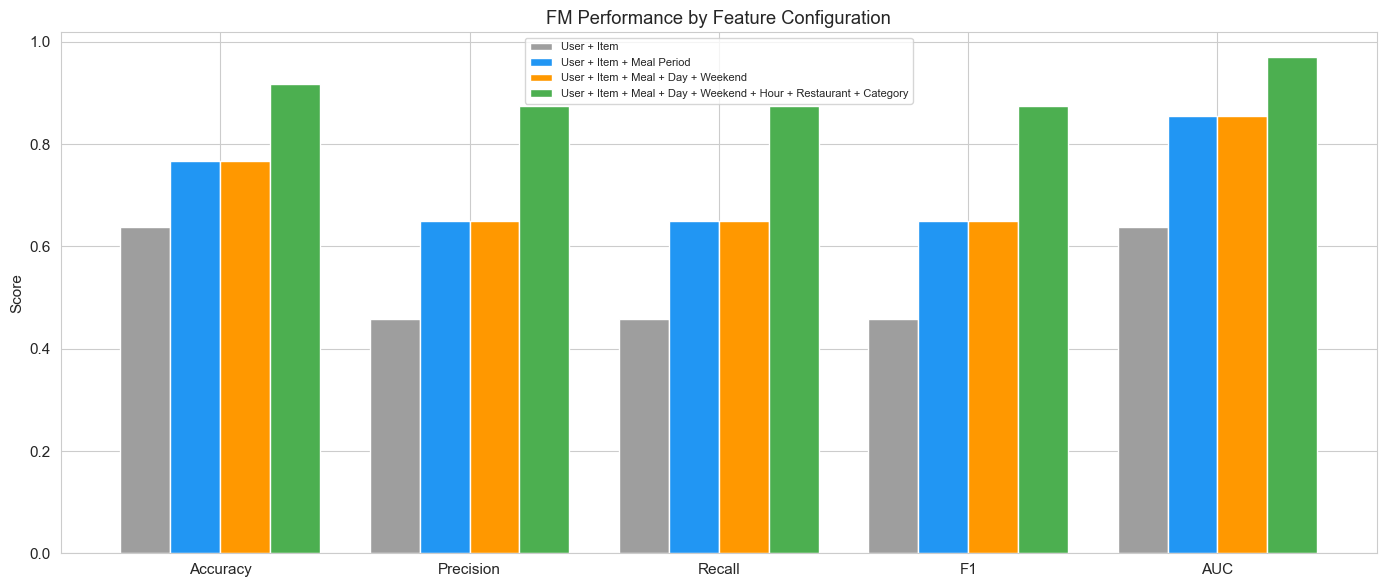

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
mk = ['accuracy', 'precision', 'recall', 'f1', 'auc']
ml = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(ml)); w = 0.2

for i, (ck, color) in enumerate(zip(configs.keys(), colors_config)):
    vals = [fm_results[ck][m] for m in mk]
    ax.bar(x + i * w, vals, w, label=fm_results[ck]['name'], color=color, edgecolor='white')

ax.set_ylabel('Score'); ax.set_title('FM Performance by Feature Configuration')
ax.set_xticks(x + 1.5 * w); ax.set_xticklabels(ml); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 9. Recommendation-Level Evaluation (Precision@K, Recall@K)

Classification metrics evaluate individual predictions. Now we evaluate as a recommendation system: rank all items for each user-context and check if real purchases appear in the top-K.

In [17]:
def evaluate_fm_recommendations(fm_model, test_data, config_key, top_k=5):
    test_pos = test_data[test_data['label'] == 1].copy()
    ctx_cols = ['user_idx', 'hour', 'day_of_week', 'is_weekend', 'meal_idx', 'restaurant_idx']
    groups = test_pos.groupby(ctx_cols)['item_idx'].apply(set).reset_index()
    groups.columns = ctx_cols + ['true_items']

    prec_s, rec_s, ndcg_s = [], [], []
    for _, row in groups.iterrows():
        ti = row['true_items']
        if not ti: continue
        ad = pd.DataFrame({
            'user_idx': [row['user_idx']] * n_items, 'item_idx': list(range(n_items)),
            'hour': [row['hour']] * n_items, 'day_of_week': [row['day_of_week']] * n_items,
            'is_weekend': [row['is_weekend']] * n_items, 'meal_idx': [row['meal_idx']] * n_items,
            'restaurant_idx': [row['restaurant_idx']] * n_items,
            'category_idx': [item_category_map.get(i, 0) for i in range(n_items)],
        })
        scores = fm_model.predict_proba(build_feature_matrix(ad, config=config_key))
        ranked = np.argsort(-scores)[:top_k]
        hits = len(set(ranked) & ti)
        prec_s.append(hits / top_k)
        rec_s.append(hits / len(ti))
        dcg = sum(1.0/np.log2(r+2) for r, it in enumerate(ranked) if it in ti)
        idcg = sum(1.0/np.log2(i+2) for i in range(min(len(ti), top_k)))
        ndcg_s.append(dcg/idcg if idcg > 0 else 0.0)

    p, r = np.mean(prec_s), np.mean(rec_s)
    return {'precision@k': p, 'recall@k': r, 'f1@k': 2*p*r/(p+r) if (p+r) > 0 else 0, 'ndcg@k': np.mean(ndcg_s)}

print('Evaluating FM configs as recommendation systems...\n')
fm_rec_results = {}
for ck, cn in configs.items():
    m = evaluate_fm_recommendations(fm_results[ck]['model'], test_data, ck, top_k=5)
    fm_rec_results[ck] = m
    print(f'  {cn:<55} | P@5: {m["precision@k"]:.4f} | R@5: {m["recall@k"]:.4f} | F1@5: {m["f1@k"]:.4f} | NDCG@5: {m["ndcg@k"]:.4f}')

Evaluating FM configs as recommendation systems...

  User + Item                                             | P@5: 0.0249 | R@5: 0.0960 | F1@5: 0.0396 | NDCG@5: 0.0625
  User + Item + Meal Period                               | P@5: 0.0458 | R@5: 0.1769 | F1@5: 0.0727 | NDCG@5: 0.1143
  User + Item + Meal + Day + Weekend                      | P@5: 0.0462 | R@5: 0.1782 | F1@5: 0.0734 | NDCG@5: 0.1151
  User + Item + Meal + Day + Weekend + Hour + Restaurant + Category | P@5: 0.1067 | R@5: 0.4118 | F1@5: 0.1695 | NDCG@5: 0.2663


---
## 10. Final Comparison — FM vs SVD vs ALS vs Popularity

In [18]:
svd_path = os.path.join(SVD_DIR, 'svd_evaluation_results.csv')
als_path = os.path.join(ALS_DIR, 'als_evaluation_results.csv')
comp = {}

if os.path.exists(svd_path):
    sdf = pd.read_csv(svd_path)
    pr = sdf[sdf['model']=='Popularity Baseline'].iloc[0]
    comp['Popularity Baseline'] = {k: pr[k] for k in ['precision@k','recall@k','f1@k','ndcg@k']}
    bs = sdf[sdf['model']!='Popularity Baseline'].sort_values('f1@k', ascending=False).iloc[0]
    comp[bs['model']] = {k: bs[k] for k in ['precision@k','recall@k','f1@k','ndcg@k']}
    print(f'Loaded: {bs["model"]}')

if os.path.exists(als_path):
    adf = pd.read_csv(als_path)
    ba = adf[(adf['model']!='Popularity Baseline') & (adf['model'].str.contains('Final'))]
    if len(ba) > 0:
        ba = ba.iloc[0]
        comp[ba['model']] = {k: ba[k] for k in ['precision@k','recall@k','f1@k','ndcg@k']}
        print(f'Loaded: {ba["model"]}')

comp['FM (User+Item only)'] = fm_rec_results['user_item']
comp['FM (Full Context)'] = fm_rec_results['full']

print(f'\n{"="*90}')
print('FINAL CROSS-MODEL COMPARISON')
print(f'{"="*90}')
print(f'{"Model":<45} | {"P@5":>6} | {"R@5":>6} | {"F1@5":>6} | {"NDCG@5":>7}')
print(f'{"-"*45}-+-{"-"*6}-+-{"-"*6}-+-{"-"*6}-+-{"-"*7}')
for nm, mt in comp.items():
    print(f'{nm:<45} | {mt["precision@k"]:>6.4f} | {mt["recall@k"]:>6.4f} | {mt["f1@k"]:>6.4f} | {mt["ndcg@k"]:>7.4f}')

Loaded: SVD (k=10)
Loaded: ALS Final (k=10, α=10, λ=0.1)

FINAL CROSS-MODEL COMPARISON
Model                                         |    P@5 |    R@5 |   F1@5 |  NDCG@5
----------------------------------------------+--------+--------+--------+--------
Popularity Baseline                           | 0.0590 | 0.1018 | 0.0747 |  0.0994
SVD (k=10)                                    | 0.2040 | 0.3736 | 0.2639 |  0.3285
ALS Final (k=10, α=10, λ=0.1)                 | 0.1968 | 0.3677 | 0.2564 |  0.3142
FM (User+Item only)                           | 0.0249 | 0.0960 | 0.0396 |  0.0625
FM (Full Context)                             | 0.1067 | 0.4118 | 0.1695 |  0.2663


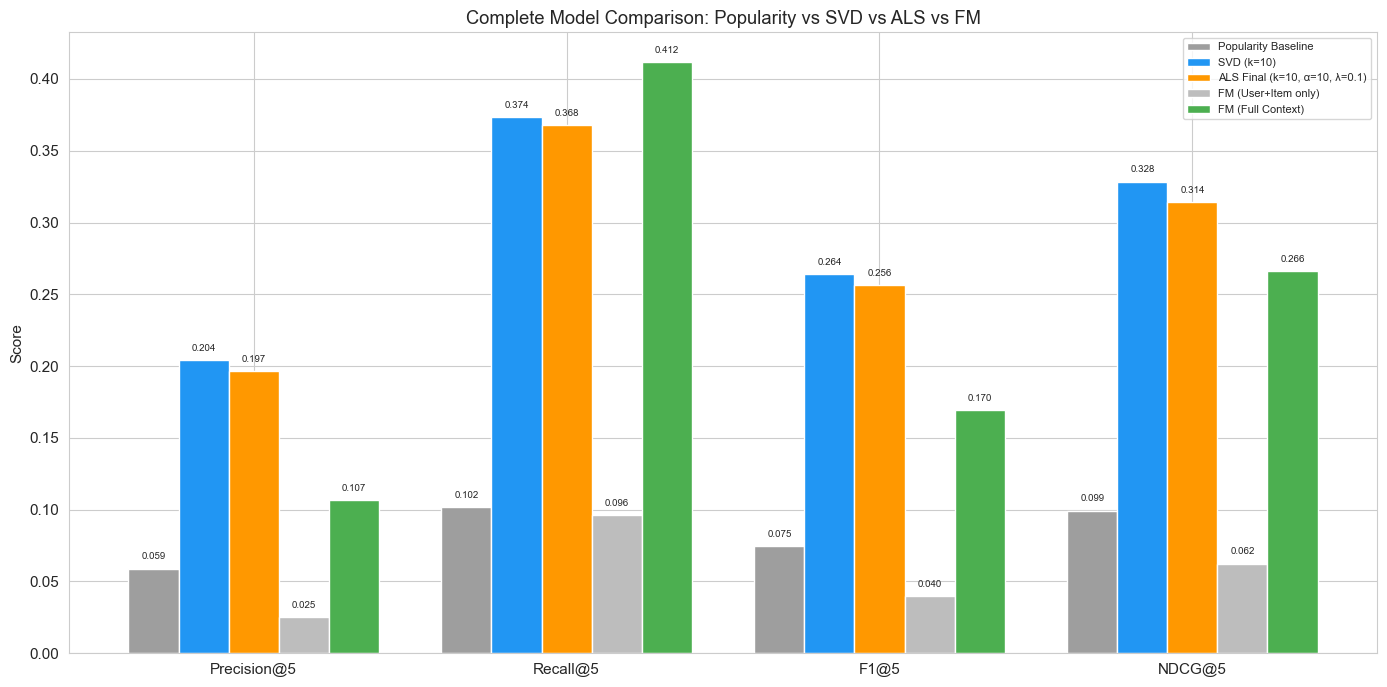

In [19]:
fig, ax = plt.subplots(figsize=(14, 7))
mnames = list(comp.keys())
mks = ['precision@k','recall@k','f1@k','ndcg@k']
mls = ['Precision@5','Recall@5','F1@5','NDCG@5']
x = np.arange(len(mls)); nm = len(mnames); w = 0.8/nm
pal = ['#9E9E9E','#2196F3','#FF9800','#BDBDBD','#4CAF50']

for i, (name, color) in enumerate(zip(mnames, pal[:nm])):
    vals = [comp[name][k] for k in mks]
    bars = ax.bar(x+i*w, vals, w, label=name, color=color, edgecolor='white')
    for bar in bars:
        if bar.get_height() > 0.01:
            ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_ylabel('Score'); ax.set_title('Complete Model Comparison: Popularity vs SVD vs ALS vs FM')
ax.set_xticks(x+(nm-1)*w/2); ax.set_xticklabels(mls); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 11. Context-Aware Demo — Same User, Different Contexts

In [20]:
def get_fm_recommendations(fm_model, user_idx, hour, day_of_week, is_weekend, meal_idx, restaurant_idx, n=5):
    ad = pd.DataFrame({
        'user_idx': [user_idx]*n_items, 'item_idx': list(range(n_items)),
        'hour': [hour]*n_items, 'day_of_week': [day_of_week]*n_items,
        'is_weekend': [is_weekend]*n_items, 'meal_idx': [meal_idx]*n_items,
        'restaurant_idx': [restaurant_idx]*n_items,
        'category_idx': [item_category_map.get(i,0) for i in range(n_items)],
    })
    scores = fm_model.predict_proba(build_feature_matrix(ad, config='full'))
    top_idx = np.argsort(-scores)[:n]
    return [(item_encoder.inverse_transform([i])[0], scores[i]) for i in top_idx]

best_fm = fm_results['full']['model']
meal_classes = list(meal_encoder.classes_)
rest_classes = list(restaurant_encoder.classes_)

# Pick a user who visits MULTIPLE restaurant types (diverse behavior)
# Filter: must exist in customers_df AND not be anonymous (customer_id > 0)
valid_customer_ids = set(customers_df['customer_id'])
valid_user_idxs = set()
for uid in df['user_idx'].unique():
    cid = user_encoder.inverse_transform([uid])[0]
    if cid in valid_customer_ids and cid > 0:
        valid_user_idxs.add(uid)

user_rest_diversity = df[df['user_idx'].isin(valid_user_idxs)].groupby('user_idx')['restaurant_type'].nunique()
diverse_users = user_rest_diversity[user_rest_diversity >= 3].index
user_txn_counts = df[df['user_idx'].isin(diverse_users)].groupby('user_idx').size()
du_idx = user_txn_counts.sort_values(ascending=False).index[0]
du_id = user_encoder.inverse_transform([du_idx])[0]
du_info = customers_df[customers_df['customer_id']==du_id].iloc[0]

# Get this user's most common restaurants for realistic contexts
user_restaurants = df[df['user_idx']==du_idx]['restaurant_idx'].value_counts()
print(f'Demo Customer: {du_id} ({du_info["archetype"]}) | Sections: {du_info["preferred_sections"]}')
print(f'Total transactions: {user_txn_counts.loc[du_idx]}')
print(f'Visits: {", ".join([restaurant_encoder.inverse_transform([r])[0] + f" ({c}x)" for r, c in user_restaurants.head(4).items()])}')

# Get restaurant indices for different contexts
cafe_idx = restaurant_encoder.transform(['Cafe'])[0] if 'Cafe' in restaurant_encoder.classes_ else user_restaurants.index[0]
american_idx = restaurant_encoder.transform(['American'])[0] if 'American' in restaurant_encoder.classes_ else user_restaurants.index[0]
italian_idx = restaurant_encoder.transform(['Italian'])[0] if 'Italian' in restaurant_encoder.classes_ else user_restaurants.index[0]
japanese_idx = restaurant_encoder.transform(['Japanese'])[0] if 'Japanese' in restaurant_encoder.classes_ else user_restaurants.index[0]

contexts = [
    {'name': 'Monday 8AM — Breakfast at Café',           'hour': 8,  'dow': 0, 'we': 0, 'meal': 'breakfast', 'rest': cafe_idx},
    {'name': 'Wednesday 12PM — Lunch at American',       'hour': 12, 'dow': 2, 'we': 0, 'meal': 'lunch',     'rest': american_idx},
    {'name': 'Friday 8PM — Dinner at Italian',           'hour': 20, 'dow': 4, 'we': 0, 'meal': 'dinner',    'rest': italian_idx},
    {'name': 'Saturday 1PM — Weekend Lunch at Japanese', 'hour': 13, 'dow': 5, 'we': 1, 'meal': 'lunch',     'rest': japanese_idx},
    {'name': 'Sunday 10AM — Weekend Breakfast at Café',  'hour': 10, 'dow': 6, 'we': 1, 'meal': 'breakfast', 'rest': cafe_idx},
]

print(f'\n{"="*70}')
print('CONTEXT-AWARE RECOMMENDATIONS')
print('Same user → different contexts → different recommendations')
print(f'{"="*70}')

for ctx in contexts:
    mi = meal_classes.index(ctx['meal']) if ctx['meal'] in meal_classes else 0
    recs = get_fm_recommendations(best_fm, du_idx, ctx['hour'], ctx['dow'], ctx['we'], mi, ctx['rest'], n=5)
    print(f'\n  {ctx["name"]}:')
    for item, score in recs:
        print(f'    {item} (score: {score:.4f})')

Demo Customer: 1320 (regular) | Sections: Mexican,Japanese
Total transactions: 102
Visits: Mexican (39x), Japanese (39x), American (12x), Italian (9x)

CONTEXT-AWARE RECOMMENDATIONS
Same user → different contexts → different recommendations

  Monday 8AM — Breakfast at Café:
    Oatmeal with Berries (score: 0.9211)
    Avocado Toast (score: 0.9191)
    Breakfast Sandwich (Egg & Cheese) (score: 0.9032)
    Blueberry Muffin (score: 0.8998)
    Everything Bagel with Cream Cheese (score: 0.8960)

  Wednesday 12PM — Lunch at American:
    Hot Dog with Mustard (score: 0.9112)
    Spicy BBQ Bacon Burger (score: 0.8802)
    Chicken Tenders (4pc) (score: 0.8792)
    Bacon Double Burger (score: 0.8778)
    Crispy Chicken Sandwich (score: 0.8477)

  Friday 8PM — Dinner at Italian:
    Margherita Pizza (score: 0.7832)
    Beef Lasagna (score: 0.7798)
    Meatball Calzone (score: 0.7770)
    Fettuccine Alfredo (score: 0.7598)
    Pepperoni Pizza (score: 0.7589)

  Saturday 1PM — Weekend Lunch at Ja

---
## 12. Save Outputs

In [21]:
# Save evaluation results
rows = []
for ck, cn in configs.items():
    row = {'model': f'FM ({cn})', **{k: fm_results[ck][k] for k in ['test_loss','accuracy','precision','recall','f1','auc']}}
    if ck in fm_rec_results:
        row.update({f'{k.replace("@k","@5")}': v for k, v in fm_rec_results[ck].items()})
    rows.append(row)
pd.DataFrame(rows).to_csv(os.path.join(FM_DIR, 'fm_evaluation_results.csv'), index=False)
print('Saved: fm_evaluation_results.csv')

# Save model
np.savez(os.path.join(FM_DIR, 'fm_model_params.npz'), w0=best_fm.w0, w=best_fm.w, V=best_fm.V)
print('Saved: fm_model_params.npz')

# Save cross-model comparison
pd.DataFrame([{'model': n, **m} for n, m in comp.items()]).to_csv(os.path.join(FM_DIR, 'full_model_comparison.csv'), index=False)
print('Saved: full_model_comparison.csv')

# Save encoders
import pickle
with open(os.path.join(FM_DIR, 'fm_encoders.pkl'), 'wb') as f:
    pickle.dump({'user': user_encoder, 'item': item_encoder, 'meal': meal_encoder, 'restaurant': restaurant_encoder, 'category': category_encoder}, f)
print('Saved: fm_encoders.pkl')

Saved: fm_evaluation_results.csv
Saved: fm_model_params.npz
Saved: full_model_comparison.csv
Saved: fm_encoders.pkl


---
## 13. Summary & Conclusions

In [22]:
print('=' * 70)
print('FACTORIZATION MACHINES — SUMMARY')
print('=' * 70)
print(f'\nDataset: {n_users} users × {n_items} items × {len(df):,} transactions')
print(f'Training samples: {len(y_train):,} | Test: {len(y_test):,}')
print(f'FM config: k=10, lr=0.01, reg=0.01, 25 epochs, batch=256')

print(f'\n--- Context Feature Impact ---')
for ck, cn in configs.items():
    print(f'  {cn:<55} | AUC: {fm_results[ck]["auc"]:.4f} | F1: {fm_results[ck]["f1"]:.4f}')

ba = fm_results['user_item']['auc']
fa = fm_results['full']['auc']
d = (fa-ba)/ba*100 if ba > 0 else 0
if d > 0:
    print(f'\n  ✅ Context features improved AUC by {d:+.1f}%')
else:
    print(f'\n  ⚠️  Context features did not improve AUC ({d:+.1f}%)')

print(f'\n--- How the 3 Models Work Together in Production ---')
print(f'  1. FP-Growth  → New customer, no history → basket-level associations')
print(f'  2. SVD        → Returning customer → personalized from purchase history')
print(f'  3. FM         → Context layer → re-ranks based on time/day/restaurant')

print(f'\n--- FM Model Characteristics ---')
print(f'  ✓ Real SGD training with epochs, learning rate, convergence')
print(f'  ✓ Learns pairwise feature interactions (user×item, item×time, user×restaurant)')
print(f'  ✓ Handles arbitrary context (time, location, category)')
print(f'  ✓ Saved: fm_model_params.npz + fm_encoders.pkl')

print(f'\n{"="*70}')
print(f'  Recommendation Module Complete.')
print(f'  Models: FP-Growth → SVD/ALS → Factorization Machines')
print(f'{"="*70}')

FACTORIZATION MACHINES — SUMMARY

Dataset: 9991 users × 122 items × 178,839 transactions
Training samples: 417,245 | Test: 104,312
FM config: k=10, lr=0.01, reg=0.01, 25 epochs, batch=256

--- Context Feature Impact ---
  User + Item                                             | AUC: 0.6383 | F1: 0.4575
  User + Item + Meal Period                               | AUC: 0.8558 | F1: 0.6507
  User + Item + Meal + Day + Weekend                      | AUC: 0.8552 | F1: 0.6503
  User + Item + Meal + Day + Weekend + Hour + Restaurant + Category | AUC: 0.9702 | F1: 0.8752

  ✅ Context features improved AUC by +52.0%

--- How the 3 Models Work Together in Production ---
  1. FP-Growth  → New customer, no history → basket-level associations
  2. SVD        → Returning customer → personalized from purchase history
  3. FM         → Context layer → re-ranks based on time/day/restaurant

--- FM Model Characteristics ---
  ✓ Real SGD training with epochs, learning rate, convergence
  ✓ Learns pairwis